# Tutorial 05 — Redes convolucionais, simetria e filtros

**Resoluções comentadas em português.** Material de estudo preparado com assistência de IA a partir de MM845 (Edward Hirst e Tomás S. R. Silva). Não é um gabarito oficial, nem um relato de execução no computador pessoal de Nina.

Os enunciados originais são preservados antes de cada solução. As saídas desta cópia são produzidas pela execução das células; os parâmetros e as sementes estão explícitos. As conclusões empíricas valem para esses experimentos, não como teoremas gerais.

[Mini-relatório](README.md) · [Material original](../../material_original/)

In [1]:
from pathlib import Path
import sys, os
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "estudos" / "comum.py").exists()), None)
if ROOT is None: raise RuntimeError("Abra este notebook dentro da pasta MM845-resolvido.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from estudos.comum import *
from IPython.display import display, Markdown
rng = np.random.default_rng(SEED + 5)
torch.manual_seed(SEED + 5)
OUT = ROOT / "estudos" / "tutorial_05" / "resultados"
OUT.mkdir(parents=True, exist_ok=True)
print("Semente:", SEED + 5, "| CPU | NumPy:", np.__version__, "| PyTorch:", torch.__version__)

Semente: 20260913 | CPU | NumPy: 2.3.5 | PyTorch: 2.10.0+cpu


## Protocolo

A curva polar é rasterizada em uma grade $32\times32$ e o rótulo de convexidade vem do sinal de $r^2+2(r')^2-rr''$. Área usa a fórmula contínua $\pi+\frac\pi2\sum_k(a_k^2+b_k^2)$. Usamos as mesmas curvas de teste antes e depois de deslocar os pixels; não trocamos o teste por outra amostra. A resolução do raster e o recorte em $[-1.5,1.5]^2$ impõem perda de informação: o rótulo contínuo não é determinado sem erro pelo raster.

**Correção de uma sutileza do material:** convoluções circulares, não linearidades ponto a ponto e média global preservam a simetria discreta de translação, mas `AvgPool2d(2)` quebra a equivariância a deslocamentos ímpares. Assim, nem toda CNN do caderno é exatamente invariante. O teste abaixo separa padding, subamostragem e acurácia; uma propriedade arquitetural não depende de a rede ter aprendido o rótulo.

Usamos modelos pequenos, 30 épocas, Adam, duas sementes no estudo de tamanho e uma execução adicional mais longa da MLP aumentada. São comparações dentro de um orçamento explícito, não uma conclusão universal de superioridade.

In [2]:
Xtr, atr, ytr = raster_curves(1400, rng)
Xte, ate, yte = raster_curves(450, rng)
Xshift = shifts(Xte, rng, max_shift=12)
print('Fração convexa treino/teste:', ytr.mean(), yte.mean())

def augmentation(x, gen):
    ds = torch.randint(-12, 13, (len(x), 2), generator=gen)
    return torch.stack([torch.roll(a, (int(d[0]), int(d[1])), (-2, -1)) for a,d in zip(x,ds)])

def fit_curve_model(kind, n, seed, epochs=30, area=False, augmented=False):
    torch.manual_seed(seed)
    model = flat_mlp() if kind=='MLP' else CNN(padding='zeros' if kind=='CNN zero' else 'circular')
    yy = atr[:n] if area else ytr[:n]
    mu, sd = (float(yy.mean()), float(yy.std())) if area else (0.,1.)
    hist=train(model,Xtr[:n],(yy-mu)/sd,epochs=epochs,lr=.002,batch_size=128,
               loss_kind='mse' if area else 'bce',shuffle_seed=seed,
               augment=augmentation if augmented else None)
    return model,hist,mu,sd

def classification(model,xx):
    return accuracy_score(yte,predict(model,xx)>=0)

# O teste arquitetural independe de treinamento.
arch=[]
for pad in ['circular','zeros']:
    for pool in [False,True]:
        torch.manual_seed(5); m=CNN(padding=pad,stride_pool=pool)
        p=predict(m,Xte[:80])
        for shift in [1,2,8]:
            delta=np.max(np.abs(p-predict(m,np.roll(Xte[:80],shift,axis=-1))))
            arch.append(dict(padding=pad,subamostragem=pool,deslocamento=shift,erro_max=delta))
            if pad=='circular' and (not pool or shift%2==0): assert delta<2e-6
arch=table(arch,'teste_simetria_arquitetural',OUT)

Fração convexa treino/teste: 0.47214285714285714 0.45555555555555555


 padding  subamostragem  deslocamento     erro_max
circular          False             1 9.313226e-10
circular          False             2 9.313226e-10
circular          False             8 9.313226e-10
circular           True             1 6.607734e-05
circular           True             2 1.862645e-09
circular           True             8 9.313226e-10
   zeros          False             1 1.525804e-04
   zeros          False             2 1.956224e-04
   zeros          False             8 2.146643e-04
   zeros           True             1 1.027165e-04
   zeros           True             2 1.160549e-04
   zeros           True             8 2.669068e-04


## Exercício 1

> **Exercise 1 — how much is the symmetry worth?**
> (a) Retrain the MLP with random translations applied during training
> (augmentation). How much of the gap does it close, and at what cost in epochs?
>
> (b) Sweep the training-set size for both models and plot accuracy against $N$.
> The claim in Lecture 5 is that the constrained model is more **sample-efficient**;
> confirm or refute it.
>
> (c) Replace `padding_mode="circular"` with the default zero padding. The
> equivariance of §1 is then only approximate near the boundary — measure how much
> accuracy on the translated set degrades, and explain why.

### Resolução

**(a) Aumentar dados aproxima uma simetria; não a torna exata.** Para cada minibatch da MLP, aplicamos um deslocamento circular independente por imagem, sem alterar o rótulo. Comparamos 10, 20 e 30 épocas e estendemos a MLP aumentada até 90 épocas. A rede vê novas translações das mesmas curvas: o número de objetos independentes continua $N$. Reportamos a diferença de acurácia e o número de épocas para atingir a referência, quando atingida; um resultado não alcançado é censurado, não contado como sucesso.

**(b) Eficiência amostral é uma propriedade do protocolo completo.** O gráfico usa $N=100,300,700,1400$, duas inicializações e o mesmo teste. Se a CNN vencer com menos curvas, isso sustenta a hipótese nessa distribuição. Se perder ou empatar, a hipótese não foi confirmada sob esse orçamento. Também exibimos a acurácia majoritária, pois o desequilíbrio de classes pode produzir um classificador aparentemente bom sem aprender convexidade.

**(c) Zero padding cria uma borda distinguível.** A translação circular do dado move massa de um lado ao outro; o padding por zeros não acompanha essa identificação. Medimos tanto acurácia quanto alteração dos logits da *mesma* imagem. A queda pode ser pequena, nula ou negativa por acaso: ausência de equivariância é uma possibilidade de erro, não uma prova de degradação da acurácia em toda amostra. A tabela de simetria acima isola ainda a quebra devida ao pooling.

           modelo  epocas  centrada  transladada  variacao_media_logit
              MLP      30  0.748889     0.553333             12.812051
MLP + translações      90  0.706667     0.711111              0.725971
     CNN circular      30  0.544444     0.544444              0.000217
         CNN zero      30  0.562222     0.577778              0.172517
           modelo  epocas  acuracia_centrada  acuracia_transladada
              MLP      10           0.751111              0.537778
              MLP      20           0.733333              0.540000
              MLP      30           0.748889              0.553333
MLP + translações      10           0.544444              0.604444
MLP + translações      20           0.680000              0.653333
MLP + translações      30           0.655556              0.655556
MLP + translações      40           0.735556              0.642222
MLP + translações      50           0.657778              0.717778
MLP + translações      60           0.6977

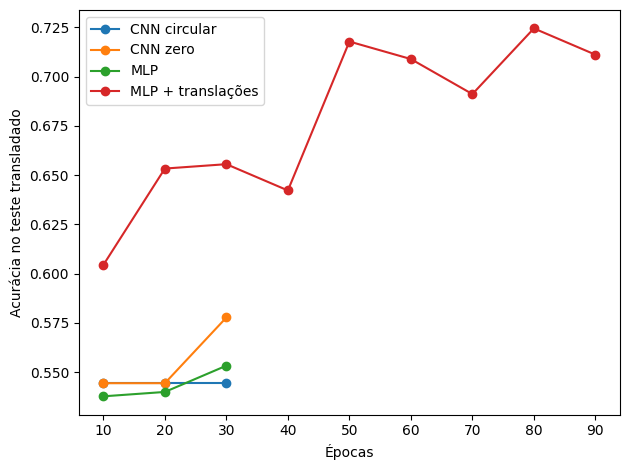

   N  semente       modelo  centrada  transladada
 100       21          MLP  0.746667     0.537778
 100       21 CNN circular  0.544444     0.544444
 100       22          MLP  0.768889     0.542222
 100       22 CNN circular  0.544444     0.544444
 300       21          MLP  0.742222     0.540000
 300       21 CNN circular  0.544444     0.544444
 300       22          MLP  0.731111     0.540000
 300       22 CNN circular  0.544444     0.544444
 700       21          MLP  0.728889     0.560000
 700       21 CNN circular  0.544444     0.544444
 700       22          MLP  0.726667     0.557778
 700       22 CNN circular  0.544444     0.544444
1400       21          MLP  0.744444     0.548889
1400       21 CNN circular  0.737778     0.737778
1400       22          MLP  0.733333     0.553333
1400       22 CNN circular  0.544444     0.544444


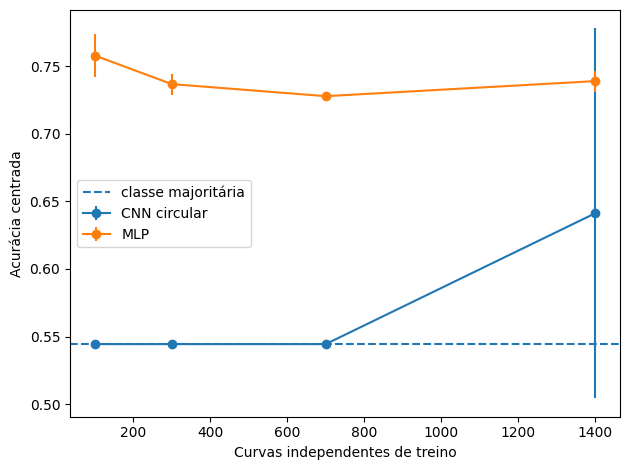

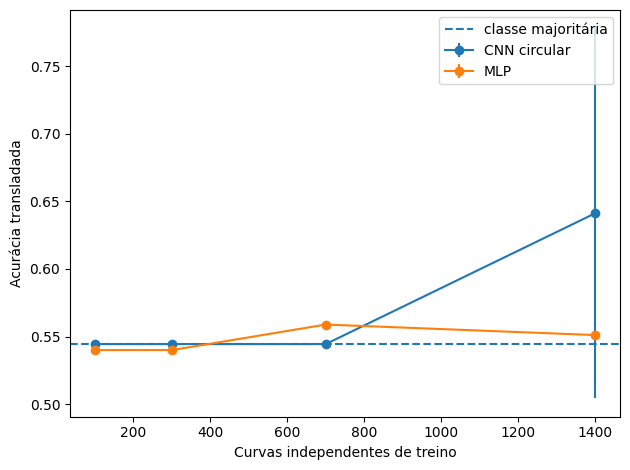

MLP−CNN por N (teste transladado):
N
100    -0.004444
300    -0.004444
700     0.014444
1400   -0.090000
Name: MLP, dtype: float64


In [3]:
rows=[]; models={}; learning=[]
for kind,aug,label in [('MLP',False,'MLP'),('MLP',True,'MLP + translações'),
                       ('CNN circular',False,'CNN circular'),('CNN zero',False,'CNN zero')]:
    torch.manual_seed(11)
    m=flat_mlp() if kind=='MLP' else CNN(padding='zeros' if kind=='CNN zero' else 'circular')
    opt=torch.optim.Adam(m.parameters(),lr=.002)
    g=torch.Generator().manual_seed(11)
    tx=torch.tensor(Xtr);ty=torch.tensor(ytr[:,None],dtype=torch.float32)
    total_epochs=90 if aug else 30
    for epoch in range(1,total_epochs+1):
        m.train();order=torch.randperm(len(tx),generator=g)
        for start in range(0,len(tx),128):
            ix=order[start:start+128]; xx=tx[ix]
            if aug:xx=augmentation(xx,g)
            opt.zero_grad();loss=nn.functional.binary_cross_entropy_with_logits(m(xx),ty[ix]);loss.backward();opt.step()
        if epoch%10==0:
            learning.append(dict(modelo=label,epocas=epoch,acuracia_centrada=classification(m,Xte),
                                 acuracia_transladada=classification(m,Xshift)))
    models[label]=m
    rows.append(dict(modelo=label,epocas=total_epochs,centrada=classification(m,Xte),
                     transladada=classification(m,Xshift),
                     variacao_media_logit=np.mean(np.abs(predict(m,Xte)-predict(m,Xshift)))))
comparison=table(rows,'classificacao_e_translacoes',OUT)
learn=table(learning,'custo_em_epocas',OUT)
base30=learn[(learn.modelo=='MLP')&(learn.epocas==30)].acuracia_transladada.iloc[0]
cnn30=learn[(learn.modelo=='CNN circular')&(learn.epocas==30)].acuracia_transladada.iloc[0]
aug30=learn[(learn.modelo=='MLP + translações')&(learn.epocas==30)].acuracia_transladada.iloc[0]
print('Ganho da MLP aumentada aos 30:',float(aug30-base30),'| diferença CNN−MLP aos 30:',float(cnn30-base30))
reached=learn[(learn.modelo=='MLP + translações')&(learn.acuracia_transladada>=cnn30)]
print('Primeiro checkpoint aumentado que atinge CNN aos 30:',int(reached.epocas.min()) if len(reached) else 'não atingiu até 90')
plt.figure()
for label,df in learn.groupby('modelo'):plt.plot(df.epocas,df.acuracia_transladada,marker='o',label=label)
plt.xlabel('Épocas');plt.ylabel('Acurácia no teste transladado');plt.legend();figure('custo_epocas',OUT)

sample=[]
for n in [100,300,700,1400]:
    for seed in [21,22]:
        for kind in ['MLP','CNN circular']:
            m,_,_,_=fit_curve_model(kind,n,seed)
            sample.append(dict(N=n,semente=seed,modelo=kind,centrada=classification(m,Xte),transladada=classification(m,Xshift)))
sample=table(sample,'eficiencia_amostral',OUT)
for col in ['centrada','transladada']:
    plt.figure()
    for kind,df in sample.groupby('modelo'):
        grouped=df.groupby('N')[col].agg(['mean','std'])
        plt.errorbar(grouped.index,grouped['mean'],yerr=grouped['std'],marker='o',label=kind)
    plt.axhline(max(yte.mean(),1-yte.mean()),linestyle='--',label='classe majoritária')
    plt.xlabel('Curvas independentes de treino');plt.ylabel('Acurácia '+col);plt.legend();figure('amostras_'+col,OUT)
print('MLP−CNN por N (teste transladado):')
print(sample.groupby(['N','modelo']).transladada.mean().unstack().diff(axis=1).iloc[:,-1])

## Exercício 2

> **Exercise 2 — read the filters as operators.**
> (a) Compute each kernel's sum and its first moments $\sum_{ij} k_{ij}\,i$ and
> $\sum_{ij} k_{ij}\,j$. Which channels approximate $\partial_x$, which $\partial_y$,
> and are there any that approximate a Laplacian (zero sum *and* zero first moments)?
>
> (b) Train on the *area* target instead and compare the filters. Does a different
> label produce different features, or does the boundary dominate either way?
>
> (c) Feed the network a curve and its reflection. The architecture is equivariant
> to translation but **not** to rotation or reflection — measure how much the
> prediction changes, and propose an architectural fix.

### Resolução

**(a) Momentos de filtros.** Centramos os índices em $-1,0,1$. A expansão de Taylor da correlação implementada por `Conv2d` é
$$ (K\star f)(x,y)\approx s_0 f + m_x\partial_x f+m_y\partial_y f+\tfrac12 m_{xx}\partial_{xx}f+m_{xy}\partial_{xy}f+\tfrac12m_{yy}\partial_{yy}f.$$
Assim, $s_0\simeq0$ e $|m_x|\gg|m_y|$ sugerem uma derivada em $x$; trocando os eixos, em $y$. Para um Laplaciano, além de zerar soma e primeiros momentos, é preciso $m_{xx}\simeq m_{yy}\ne0$ e $m_{xy}\simeq0$. As condições citadas no enunciado, sozinhas, **não bastam**: uma derivada mista também as satisfaz. Normalizamos os momentos pela norma $\ell^1$ do filtro; os limiares de classificação são apenas diagnósticos e canais mistos são resultados legítimos. O bias e as ativações posteriores também importam.

**(b) Rótulos diferentes induzem objetivos diferentes, mas filtros não são identificáveis.** Treinamos uma CNN de área com arquitetura idêntica, normalização do alvo calculada só no treino e mesma inicialização. Comparamos momentos e os filtros visualmente; permutar canais ou reescalá-los pode representar a mesma função. Portanto, diferenças de um canal com o mesmo índice não provam diferenças semânticas. A área pode ser aproximada contando pixels, enquanto convexidade depende mais do contorno; isso é uma motivação, não uma obrigação para cada filtro aprendido.

**(c) Reflexão.** Uma convolução usual compartilha pesos sob translação, mas não sob a ação de $D_4$. Medimos $|f(x)-f(Rx)|$. Uma correção exata para esses rasters quadrados é a média de grupo
$$f_{D_4}(x)=\frac18\sum_{g\in D_4}f(gx).$$
Para todo $h\in D_4$, a substituição $g'=gh$ prova $f_{D_4}(hx)=f_{D_4}(x)$. Implementamos e verificamos essa construção. Ela custa oito passagens e preserva rotações de 90 graus/reflexões, **não todas as rotações contínuas**; outra solução seria convolução equivariante ao grupo e pooling invariante.

MSE de área: 0.03586290689494125 | referência média: 0.0401346180980267


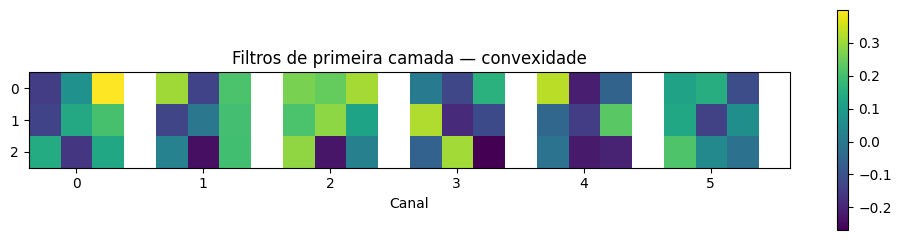

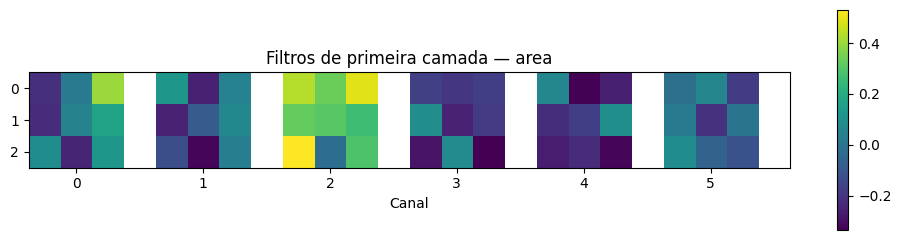

     tarefa  canal      soma        mx        my       mxx       myy       mxy             diagnostico
convexidade      0  0.415660  0.572905 -0.141383  0.388078  0.280899 -0.367229 misto/sem classificação
convexidade      1  0.296150  0.278003 -0.273266  0.559200  0.249668  0.182407 misto/sem classificação
convexidade      2  0.767776 -0.160783 -0.372505  0.616560  0.455467 -0.158347 misto/sem classificação
convexidade      3  0.020635 -0.322563 -0.039495  0.028263  0.012956 -0.231421   derivada x aproximada
convexidade      4 -0.236695 -0.204583 -0.342205  0.161616 -0.258770  0.135682 misto/sem classificação
convexidade      5  0.464543 -0.533379  0.092691  0.405218  0.406956 -0.007277 misto/sem classificação
       area      0  0.110477  0.684401 -0.156344  0.222728  0.111635 -0.376158   derivada x aproximada
       area      1 -0.575498  0.309726 -0.251944 -0.073544 -0.378307  0.181927 misto/sem classificação
       area      2  0.984932 -0.082830 -0.156005  0.777532  0.686582 -0.0

     tarefa  diferenca_media  diferenca_max  erro_max_media_D4
convexidade         0.000652       0.002286       2.980232e-08
       area         0.002366       0.010208       1.490116e-08


In [4]:
cnn=models['CNN circular']
area_net,area_hist,area_mu,area_sd=fit_curve_model('CNN circular',1400,11,epochs=35,area=True)
print('MSE de área:',mean_squared_error(ate,predict(area_net,Xte)*area_sd+area_mu),
      '| referência média:',mean_squared_error(ate,np.full_like(ate,area_mu)))

def kernel_moments(net,label):
    kernels=net.features[0].weight.detach().numpy()[:,0]
    iy,ix=np.mgrid[-1:2,-1:2];rows=[]
    for c,K in enumerate(kernels):
        norm=max(np.abs(K).sum(),1e-12)
        s,mx,my=(K.sum()/norm,(K*ix).sum()/norm,(K*iy).sum()/norm)
        xx,yy,xy=(K*ix**2).sum()/norm,(K*iy**2).sum()/norm,(K*ix*iy).sum()/norm
        label_op='misto/sem classificação'
        if abs(s)<.12 and abs(mx)>2*abs(my) and abs(mx)>.15:label_op='derivada x aproximada'
        elif abs(s)<.12 and abs(my)>2*abs(mx) and abs(my)>.15:label_op='derivada y aproximada'
        elif max(abs(s),abs(mx),abs(my),abs(xy),abs(xx-yy))<.12 and abs(xx+yy)>.2:label_op='Laplaciano aproximado'
        rows.append(dict(tarefa=label,canal=c,soma=s,mx=mx,my=my,mxx=xx,myy=yy,mxy=xy,diagnostico=label_op))
    # Uma figura, sem subplots: canais separados por coluna vazia.
    mosaic=np.concatenate([np.pad(k,((0,0),(0,1)),constant_values=np.nan) for k in kernels],axis=1)
    plt.figure(figsize=(10,2.5));plt.imshow(mosaic);plt.colorbar();plt.title('Filtros de primeira camada — '+label)
    plt.xticks(np.arange(len(kernels))*4+1,[str(i) for i in range(len(kernels))]);plt.xlabel('Canal');figure('filtros_'+label,OUT)
    return rows
moments=table(kernel_moments(cnn,'convexidade')+kernel_moments(area_net,'area'),'momentos_filtros',OUT)

def d4_predict(net,X):
    images=[np.rot90(X,k,axes=(-2,-1)).copy() for k in range(4)]
    images += [np.flip(im,axis=-1).copy() for im in images.copy()]
    return np.mean([predict(net,im) for im in images],axis=0)
reflected=np.flip(Xte,axis=-1).copy()
r=[]
for name,net in [('convexidade',cnn),('area',area_net)]:
    delta=np.abs(predict(net,Xte)-predict(net,reflected))
    gd=np.abs(d4_predict(net,Xte)-d4_predict(net,reflected))
    r.append(dict(tarefa=name,diferenca_media=delta.mean(),diferenca_max=delta.max(),erro_max_media_D4=gd.max()))
    assert gd.max()<2e-5
reflection=table(r,'reflexao_e_correcao_D4',OUT)
cnnrow=comparison[comparison.modelo=='CNN circular'].iloc[0]
mlprow=comparison[comparison.modelo=='MLP'].iloc[0]
write_summary(OUT.parent/'README.md',
 'medir o efeito de simetria, aumento de dados e filtros.',
 'equivariância depende também do padding e do passo do pooling.',
 'Comparei MLP/CNN, quatro tamanhos de treino, translações, área e reflexões.',
 f'No teste transladado, CNN={cnnrow.transladada:.3f} e MLP={mlprow.transladada:.3f}; a média D4 passou no teste de invariância.',
 'Duas sementes e rasters finitos não estabelecem uma vantagem universal de amostragem.')